In [ ]:
import os
import itertools
import copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout


RANDOM_SEED = 42

In [7]:

CSV_PATH       = "model/training.csv"
MODEL_DIR      = "model"
MODEL_FILENAME = "asl_model.keras"      
LABEL_FILENAME = "label.csv"

os.makedirs(MODEL_DIR, exist_ok=True)
MODEL_PATH = os.path.join(MODEL_DIR, MODEL_FILENAME)
LABEL_PATH = os.path.join(MODEL_DIR, LABEL_FILENAME)

print(f"Loading dataset from {CSV_PATH}...")
print(f"Saving model to {MODEL_PATH}...")
print(f"Saving labels to {LABEL_PATH}...")

Loading dataset from model/training.csv...
Saving model to model/asl_model.keras...
Saving labels to model/label.csv...


In [8]:
#preprocessing: landmark lists contains coordinates of the fingers that have been converted from 
# three dimension to two dimension (x,y)
# this method "flattens" those coordinated by normalizing values from 0 to 1
def pre_process_landmark(landmark_list):
    temp = copy.deepcopy(landmark_list)
    # shift so first landmark is at (0,0)
    base_x, base_y = temp[0][0], temp[0][1]
    for p in temp:
        p[0] -= base_x
        p[1] -= base_y
    flat = list(itertools.chain.from_iterable(temp)) # type: ignore
    m = max(map(abs, flat)) or 1.0
    return [v / m for v in flat]

In [9]:
df = pd.read_csv(CSV_PATH, header=None)
df[0] = pd.to_numeric(df[0], errors='coerce')
df = df.dropna(subset=[0])

y_raw = df.iloc[:, 0].astype(int).values           # 0–25
kp_raw = df.iloc[:, 1:].values.astype(np.float32)  # shape (,63)
df

,0,1,2,3,4,5,6,7,8,9,...,54,55,56,57,58,59,60,61,62,63
0,13.0,0.532157,0.738175,-1.088843e-07,0.629461,0.672375,0.023398,0.630278,0.579359,0.027044,...,-0.064230,0.525741,0.530009,-0.117347,0.541508,0.598408,-0.115939,0.519335,0.632886,-0.100926
1,4.0,0.522370,0.780412,-2.464444e-07,0.597483,0.732424,-0.031173,0.627620,0.638108,-0.039808,...,-0.016853,0.454154,0.510270,-0.032238,0.476973,0.529844,-0.036235,0.493105,0.570563,-0.035589
2,5.0,0.497233,0.882337,1.121043e-07,0.424596,0.833910,0.005032,0.395236,0.750907,0.007571,...,-0.029205,0.619330,0.612260,-0.038654,0.641333,0.561387,-0.033212,0.662061,0.518208,-0.023726
3,7.0,0.332408,0.633441,7.475897e-07,0.377565,0.528721,0.087212,0.458882,0.477297,0.090044,...,-0.129230,0.570587,0.615151,-0.057334,0.523985,0.629132,-0.012835,0.490286,0.634945,0.001807
4,5.0,0.514516,0.953506,5.947165e-07,0.591990,0.892410,-0.018683,0.636560,0.797684,-0.027276,...,-0.049410,0.357860,0.633999,-0.071739,0.331931,0.571604,-0.075299,0.312067,0.516713,-0.073542
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13994,22.0,0.483916,0.896195,8.173098e-07,0.559732,0.865108,-0.051222,0.605500,0.789950,-0.060309,...,-0.036089,0.487166,0.602358,-0.072234,0.522219,0.634046,-0.072039,0.532449,0.689546,-0.064822
13995,20.0,0.520840,0.777519,1.091140e-06,0.462137,0.716860,-0.079615,0.448343,0.626926,-0.076816,...,0.040974,0.546938,0.558170,-0.027855,0.547052,0.618863,-0.050975,0.536479,0.659603,-0.050918
13996,18.0,0.460739,0.675454,-4.354773e-07,0.543547,0.646460,-0.035614,0.597227,0.540238,-0.041201,...,-0.000369,0.429386,0.460871,-0.039296,0.444706,0.522139,-0.030582,0.434368,0.543362,-0.013255
13997,8.0,0.546665,0.737978,-7.977549e-07,0.633567,0.685418,-0.046654,0.680445,0.571227,-0.057091,...,0.018707,0.473003,0.381574,-0.005122,0.473854,0.327540,-0.006284,0.472366,0.271095,0.004417


In [10]:
# apply same calc_landmark_list + pre_process_landmark 
#   drop z, normalize
processed = []
for row in kp_raw:
    pts = row.reshape(-1, 3)               #(21,3)
    # build landmark_list = [[x,y],…]
    landmark_list = [[x, y] for x, y, z in pts]
    proc = pre_process_landmark(landmark_list)  #  42
    processed.append(proc)
X = np.vstack(processed)  # shape (,42)

le = LabelEncoder()
y = le.fit_transform(y_raw)      
n_classes = len(le.classes_)      # should be 26

letters = [chr(65 + i) for i in range(n_classes)]
with open(LABEL_PATH, "w", encoding="utf-8-sig") as f:
    for L in letters:
        f.write(L + "\n")
print("Wrote labels →", LABEL_PATH)

y_cat = tf.keras.utils.to_categorical(y, n_classes)
X_train, X_val, y_train, y_val = train_test_split(X, y_cat, test_size=0.2, random_state=42, stratify=y)

Wrote labels → model/label.csv


In [11]:

model = Sequential([
    Dense(128, activation="relu", input_shape=(X_train.shape[1],)),
    Dropout(0.3),
    Dense(64, activation="relu"),
    Dropout(0.3),
    Dense(n_classes, activation="softmax")
])
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=64
)

model.save(MODEL_PATH)
print("Trained model saved to", MODEL_PATH)

Epoch 1/50


/opt/anaconda3/envs/ASL-Translation/lib/python3.10/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.1544 - loss: 2.9246 - val_accuracy: 0.7325 - val_loss: 1.4244
Epoch 2/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5110 - loss: 1.4627 - val_accuracy: 0.9021 - val_loss: 0.7411
Epoch 3/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6871 - loss: 0.9484 - val_accuracy: 0.9389 - val_loss: 0.4755
Epoch 4/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7749 - loss: 0.6969 - val_accuracy: 0.9657 - val_loss: 0.3441
Epoch 5/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8358 - loss: 0.5491 - val_accuracy: 0.9671 - val_loss: 0.2693
Epoch 6/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8793 - loss: 0.4369 - val_accuracy: 0.9743 - val_loss: 0.2146
Epoch 7/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8953 - loss: 0.3700 - val_accuracy: 0.9704 - val_loss: 0.1949
Epoch 8/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9091 - loss: 0.3297 - val_accuracy: 0.9739 - val_

---


# Model building

In [25]:
# model = tf.keras.models.Sequential([
#     tf.keras.layers.Input(shape=(X_train.shape[1],)),
#     tf.keras.layers.Dropout(0.2),
#     tf.keras.layers.Dense(20, activation='relu'),
#     tf.keras.layers.Dropout(0.4),
#     tf.keras.layers.Dense(10, activation='relu'),
#     tf.keras.layers.Dense(n_classes, activation='softmax')
#])

model = Sequential([
    Dense(42, activation="relu", input_shape=(X_train.shape[1],)),
    Dropout(0.3),
    Dense(20, activation="relu"),
    Dropout(0.3),
    Dense(10, activation="relu"),
    Dense(n_classes, activation="softmax")
])

/opt/anaconda3/envs/ASL-Translation/lib/python3.10/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [26]:
model.summary()  # tf.keras.utils.plot_model(model, show_shapes=True)

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                 │ (None, 42)             │         1,806 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 42)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 20)             │           860 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 20)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │           210 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 26)             │           286 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,162 (12.35 KB)

 Trainable params: 3,162 (12.35 KB)

 Non-trainable params: 0 (0.00 B)

In [27]:
# Model checkpoint callback
cp_callback = tf.keras.callbacks.ModelCheckpoint(
    MODEL_PATH, verbose=1, save_weights_only=False)
# Callback for early stopping
es_callback = tf.keras.callbacks.EarlyStopping(patience=25, verbose=1)

In [30]:
# Model compilation
model.compile(
    optimizer='adam',
    loss="categorical_crossentropy",
    metrics=['accuracy']
)

Epoch 1/900


50/56 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.0393 - loss: 3.2754 
Epoch 1: saving model to model/asl_model.keras
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.0397 - loss: 3.2722 - val_accuracy: 0.1089 - val_loss: 3.1879
Epoch 2/900
52/56 ━━━━━━━━━━━━━━━━━━━━ 0s 991us/step - accuracy: 0.0622 - loss: 3.1731
Epoch 2: saving model to model/asl_model.keras
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.0638 - loss: 3.1691 - val_accuracy: 0.1357 - val_loss: 2.9610
Epoch 3/900
 1/56 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.1050 - loss: 3.0382
Epoch 3: saving model to model/asl_model.keras
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.1254 - loss: 2.9533 - val_accuracy: 0.2129 - val_loss: 2.6444
Epoch 4/900
 1/56 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.2150 - loss: 2.6431
Epoch 4: saving model to model/asl_model.keras
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.1843 - loss: 2.6629 - val_accuracy: 0.3079 - val_loss: 2.2582
Epoch 5/900
 1/56 ━

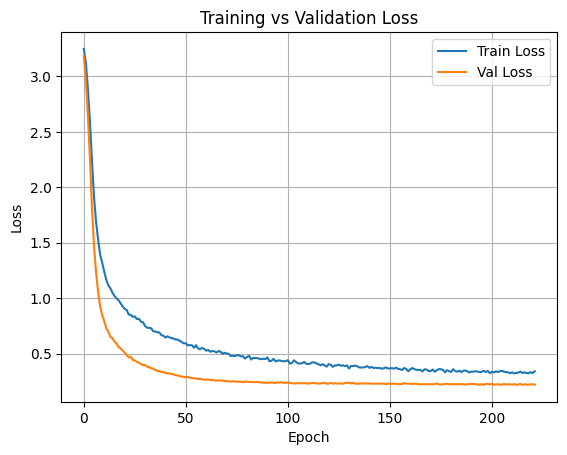

In [ ]:

history = model.fit(
    X_train,
    y_train,
    epochs=900,
    batch_size=200,
    validation_data=(X_val, y_val),
    callbacks=[cp_callback, es_callback]
)

# Plot train/val loss
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()


In [33]:
# Model evaluation
val_loss, val_acc = model.evaluate(X_val, y_val, batch_size=128)

22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9801 - loss: 0.2094 


In [35]:
# Inference test
predict_result = model.predict(np.array([X_val[0]]))
print(np.squeeze(predict_result))
print(np.argmax(np.squeeze(predict_result)))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
[9.9720552e-09 2.7699761e-19 1.0149820e-05 2.9698647e-22 1.7831582e-06
 7.1488820e-17 7.0153376e-08 5.0716325e-19 9.9946982e-01 1.8961396e-15
 1.0153617e-27 2.8345517e-18 4.4790160e-14 9.9290076e-28 8.2227880e-10
 7.8529683e-12 8.0157223e-09 1.5754544e-38 1.1645677e-10 1.8378888e-08
 5.6801783e-33 0.0000000e+00 0.0000000e+00 5.3481958e-27 5.1810901e-04
 6.4225017e-19]
8


88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 547us/step


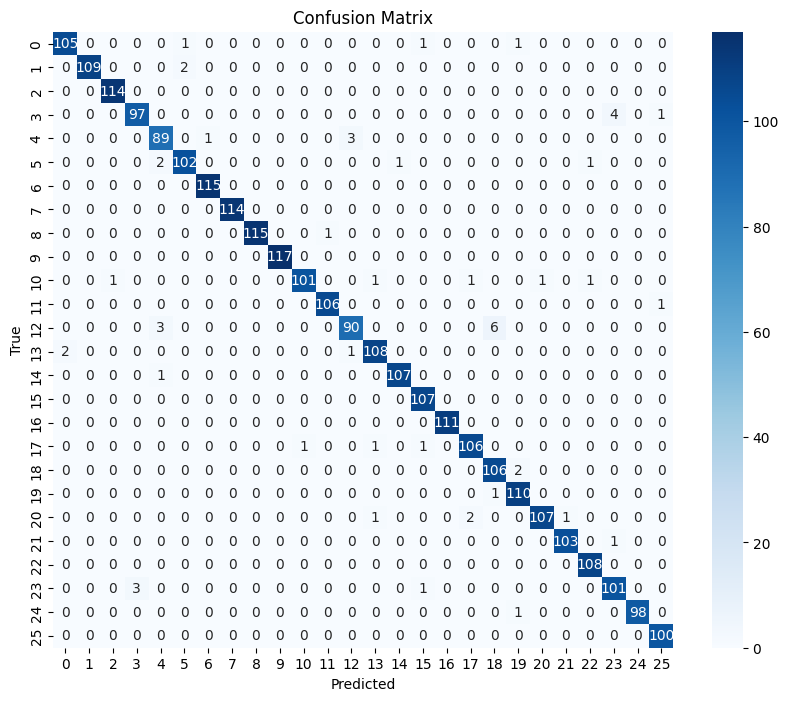

In [ ]:
# confusion matrix - see where the model is making mistakes
# sometimes the model mistakes A/T, K/Q and M/S at 98& accuracy
from sklearn.metrics import confusion_matrix
import seaborn as sns
y_pred = model.predict(X_val)
y_pred_classes = np.argmax(y_pred, axis=1)
cm = confusion_matrix(np.argmax(y_val, axis=1), y_pred_classes)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()